In [9]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

In [10]:
model_weight_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/Preprocessing/runs/segment/train8/weights/best.pt'
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/tiles/images/5_14.png'
# image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/global_images/5.jpg'


if not os.path.exists(model_weight_path):
    raise ValueError(f"Model weight path does not exist: {model_weight_path}")  
if not os.path.exists(image_path):
    raise ValueError(f"Image path does not exist: {image_path}")

img = cv2.imread(image_path)
img_resized = cv2.resize(img, (640, 640))
print("Image resized shape:", img_resized.shape)

Image resized shape: (640, 640, 3)


In [ ]:
# Load 
model = YOLO(model_weight_path)
model.info()

TypeError: YOLO.__init__() got an unexpected keyword argument 'retina_masks'

In [ ]:
# results = model.predict(source=image_path, save=True, show=False)
results = model(img_resized)


0: 640x640 15 puzzle_pieces, 63.3ms
Speed: 2.9ms preprocess, 63.3ms inference, 26.9ms postprocess per image at shape (1, 3, 640, 640)


Confidence scores: tensor([0.9447, 0.9443, 0.9426, 0.9413, 0.9368, 0.9363, 0.9218, 0.9089, 0.9035, 0.8827, 0.8572, 0.8543, 0.8460, 0.8297, 0.7077], device='cuda:0')


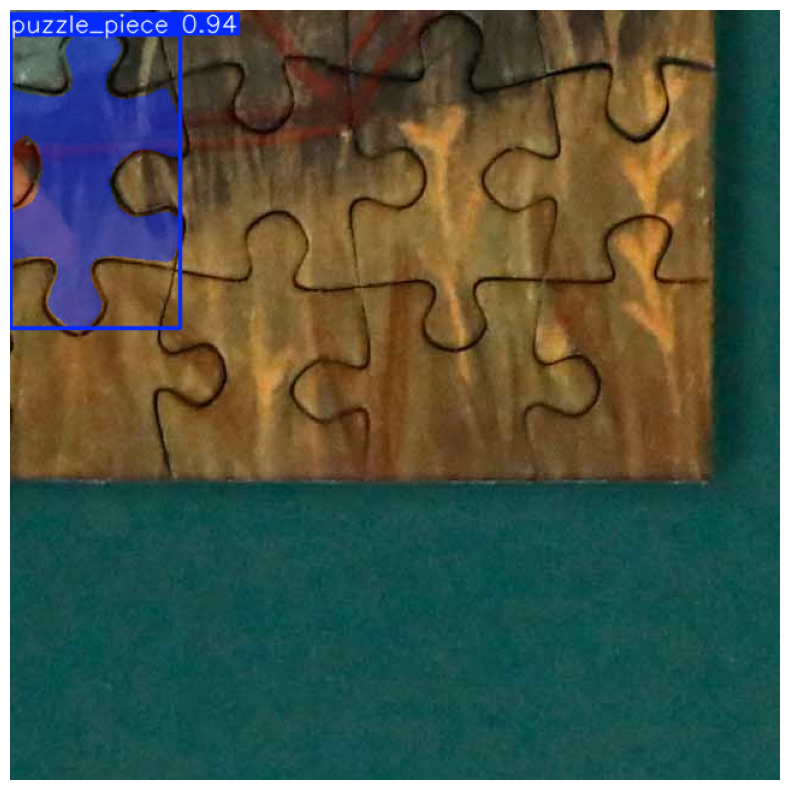

In [ ]:
# Visualize the first result
for r in results:
    confidence = r.boxes.conf
    print("Confidence scores:", confidence)

    # plot() returns a BGR numpy array
    im_bgr = r[1].plot()
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()


Filtering 1 boxes below confidence 0.8


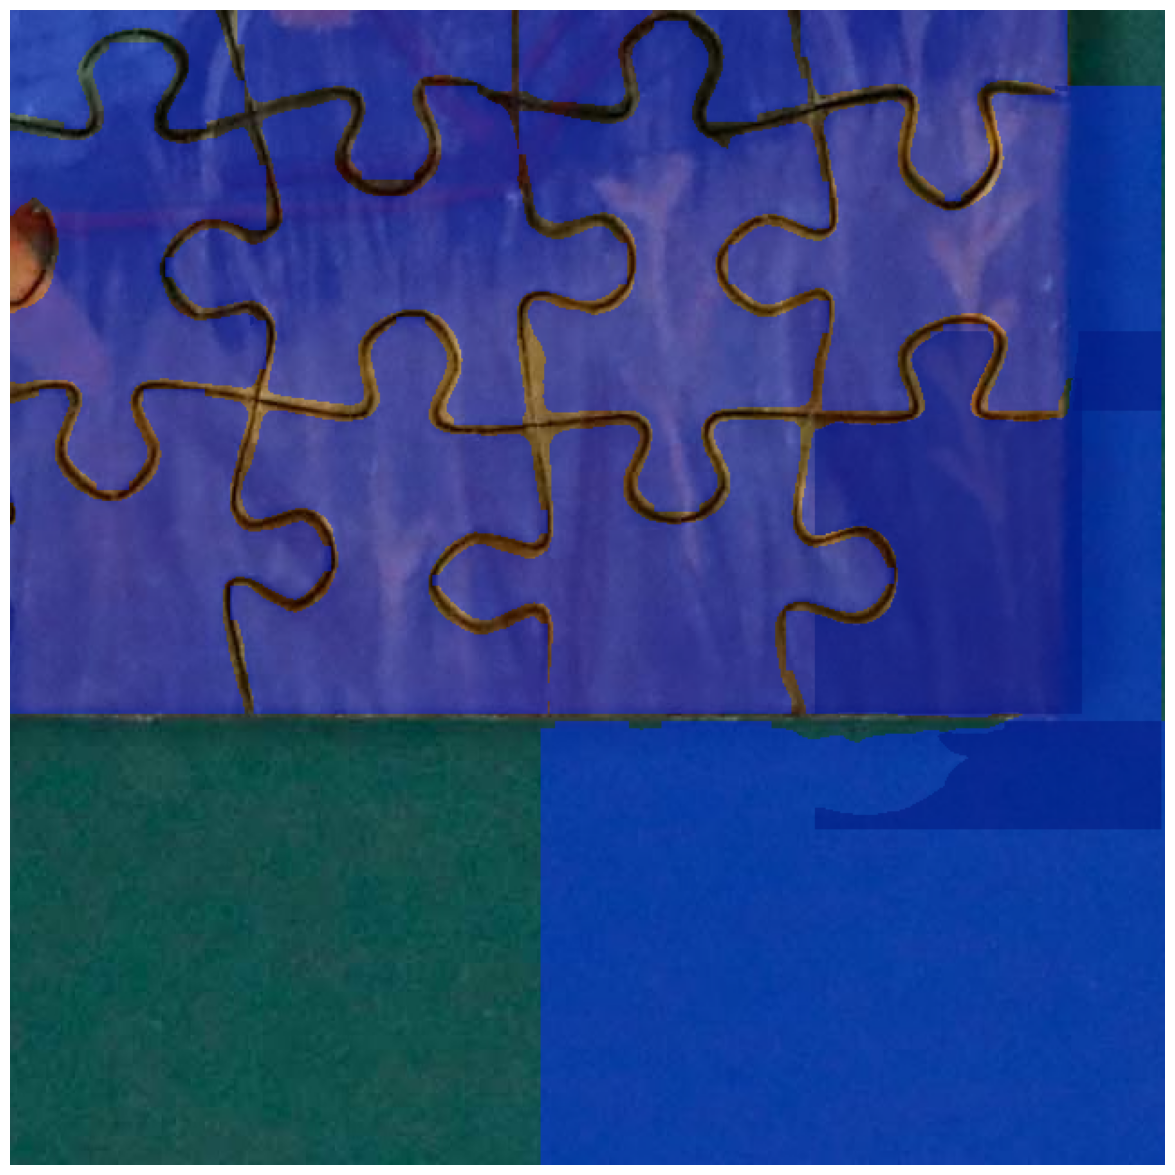

In [ ]:
conf_thresh = 0.8
r_sel = r[[True if r_i.boxes.conf > conf_thresh else False for r_i in r]]
print(f'Filtering {len(r) - len(r_sel)} boxes below confidence {conf_thresh}')


im_bgr = r_sel.plot(labels=False, boxes=False, color_mode="class", masks=True)
# # Convert BGR (OpenCV format) to RGB (Matplotlib format)
im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(im_rgb)
plt.axis('off')
plt.show()



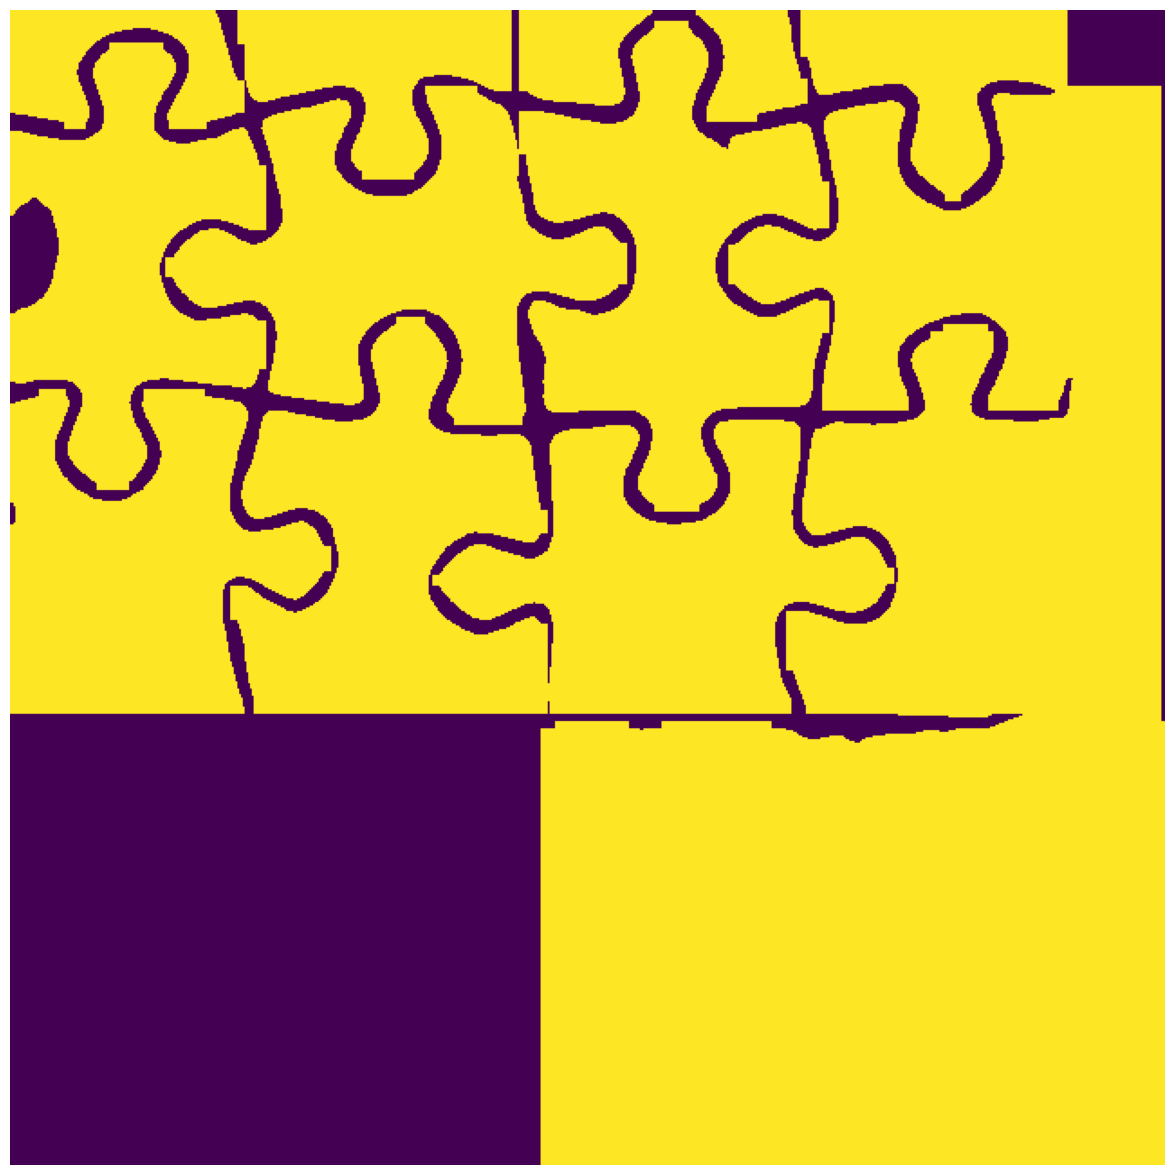

In [ ]:
conf_thresh = 0.8

im_mask = np.zeros((3, 640, 640))

masks = r_sel.masks.data  # (N, H, W), torch.Tensor

# Combine all masks into one
combined_mask = torch.any(masks.bool(), dim=0)

# Convert to uint8 image (0 or 255)
mask_image = (combined_mask.cpu().numpy().astype(np.uint8)) * 255

plt.figure(figsize=(15, 15))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

In [ ]:
ind_sel = [True if r_i.boxes.conf > conf_thresh else False for r_i in r]
r_sel = r[ind_sel]